In [ ]:
!pip install pandas numpy matplotlib seaborn plotly

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

print(df.shape)
df.head()

Saving Palo Alto Networks (1).csv to Palo Alto Networks (1).csv
(1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


In [ ]:
attrition_rate = (df['Attrition'].sum()/len(df))*100

print("Overall Attrition Rate:",round(attrition_rate,2),"%")

Overall Attrition Rate: 16.12 %


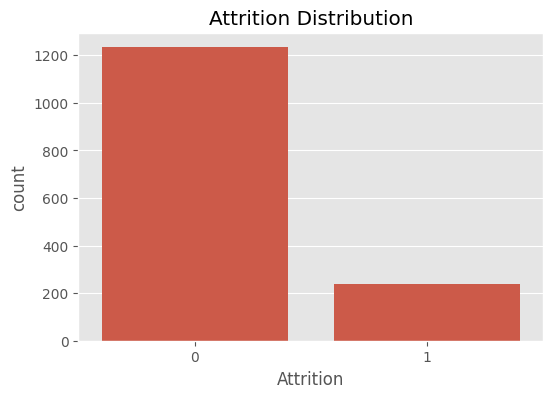

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Attrition',data=df)

plt.title("Attrition Distribution")

plt.show()

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


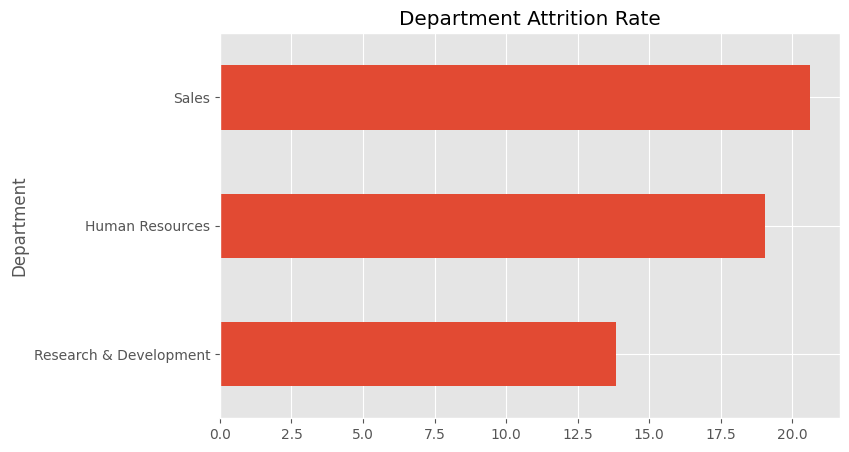

In [ ]:
dept_attrition = df.groupby('Department')['Attrition'].mean()*100

print(dept_attrition)

dept_attrition.sort_values().plot(kind='barh',figsize=(8,5))

plt.title("Department Attrition Rate")

plt.show()

JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64


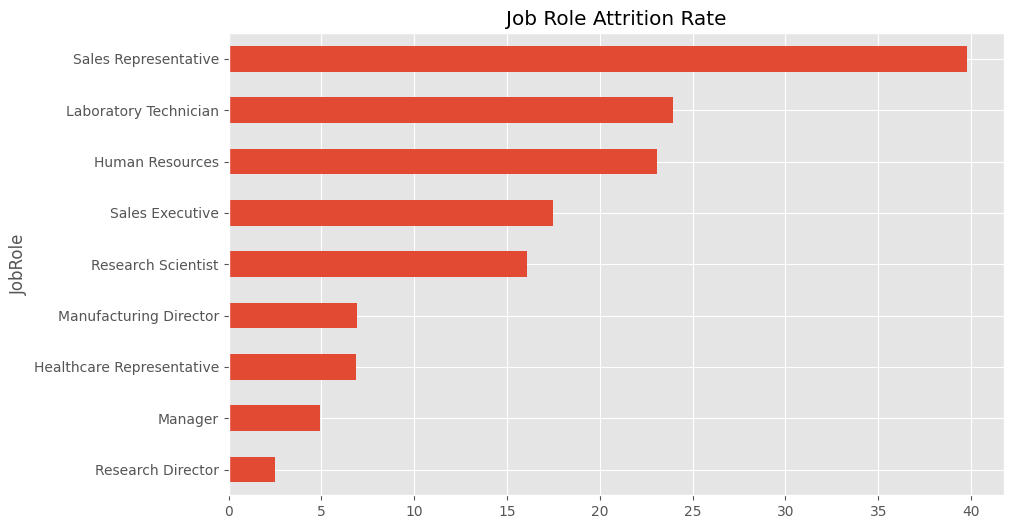

In [ ]:
role_attrition = df.groupby('JobRole')['Attrition'].mean()*100

print(role_attrition)

role_attrition.sort_values().plot(kind='barh',figsize=(10,6))

plt.title("Job Role Attrition Rate")

plt.show()

AgeGroup
18-25    34.782609
26-35    19.141914
36-45     9.188034
46-55    11.504425
56-65    17.021277
Name: Attrition, dtype: float64


/tmp/ipykernel_1088/1235786999.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition=df.groupby('AgeGroup')['Attrition'].mean()*100


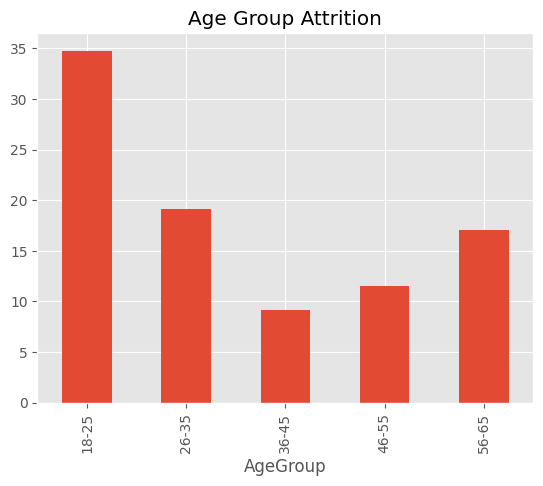

In [ ]:
df['AgeGroup']=pd.cut(df['Age'],
                      bins=[18,25,35,45,55,65],
                      labels=['18-25','26-35','36-45','46-55','56-65'])

age_attrition=df.groupby('AgeGroup')['Attrition'].mean()*100

print(age_attrition)

age_attrition.plot(kind='bar')

plt.title("Age Group Attrition")

plt.show()

Gender
Female    14.795918
Male      17.006803
Name: Attrition, dtype: float64


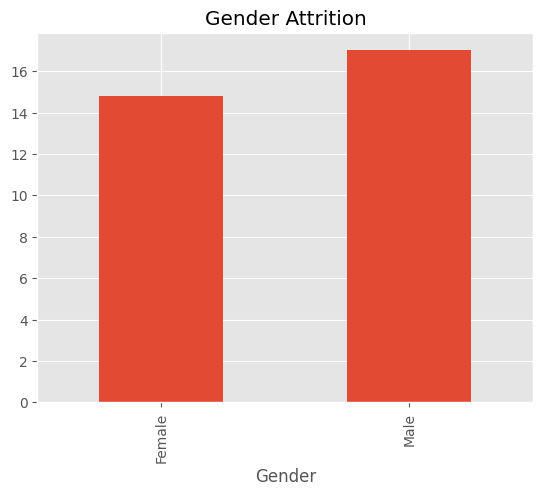

In [ ]:
gender_attrition=df.groupby('Gender')['Attrition'].mean()*100

print(gender_attrition)

gender_attrition.plot(kind='bar')

plt.title("Gender Attrition")

plt.show()

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64


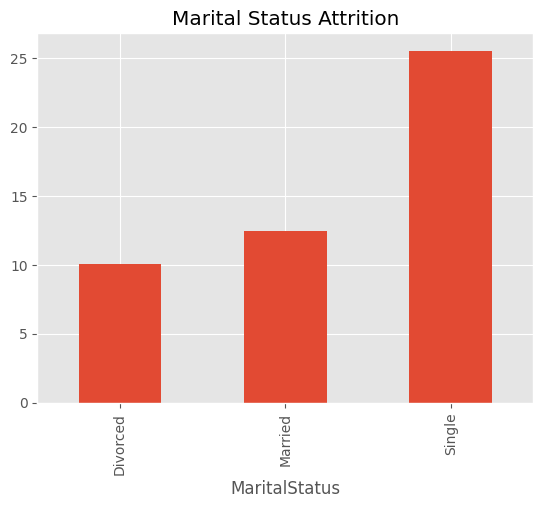

In [ ]:
marital_attrition=df.groupby('MaritalStatus')['Attrition'].mean()*100

print(marital_attrition)

marital_attrition.plot(kind='bar')

plt.title("Marital Status Attrition")

plt.show()

Education
1    18.235294
2    15.602837
3    17.307692
4    14.572864
5    10.416667
Name: Attrition, dtype: float64


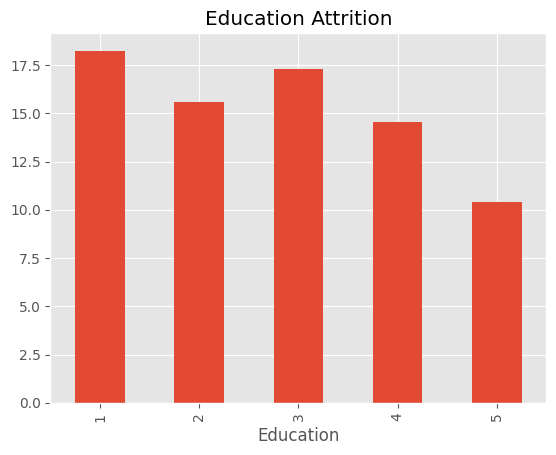

In [ ]:
edu_attrition=df.groupby('Education')['Attrition'].mean()*100

print(edu_attrition)

edu_attrition.plot(kind='bar')

plt.title("Education Attrition")

plt.show()

/tmp/ipykernel_1088/1473273433.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attrition=df.groupby('TenureBucket')['Attrition'].mean()*100


TenureBucket
0-2      28.859060
3-5      13.824885
6-10     12.276786
11-20     6.666667
20+      12.121212
Name: Attrition, dtype: float64


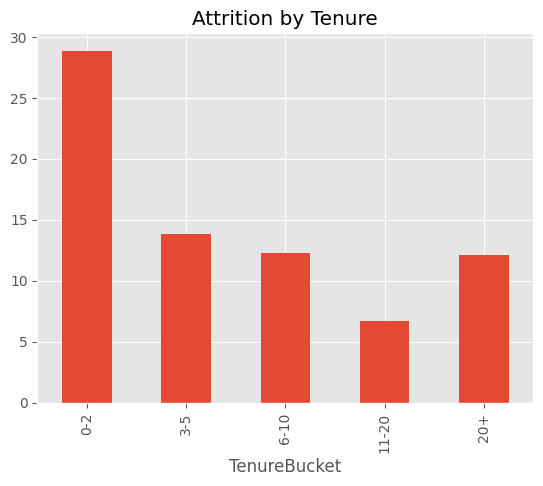

In [ ]:
df['TenureBucket']=pd.cut(df['YearsAtCompany'],
                          bins=[0,2,5,10,20,40],
                          labels=['0-2','3-5','6-10','11-20','20+'])

tenure_attrition=df.groupby('TenureBucket')['Attrition'].mean()*100

print(tenure_attrition)

tenure_attrition.plot(kind='bar')

plt.title("Attrition by Tenure")

plt.show()

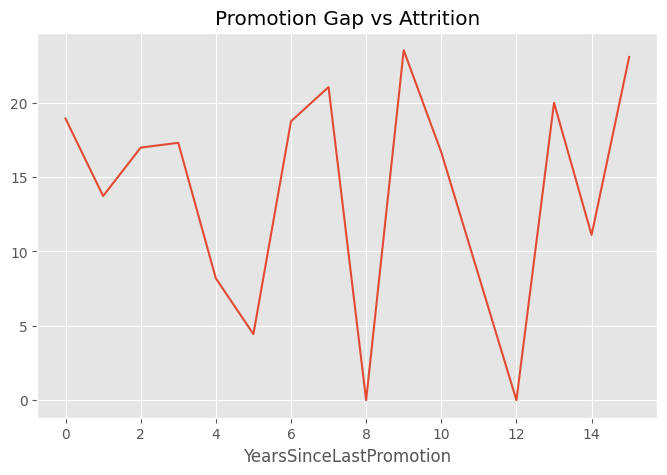

In [ ]:
promo_attrition=df.groupby('YearsSinceLastPromotion')['Attrition'].mean()*100

promo_attrition.plot(figsize=(8,5))

plt.title("Promotion Gap vs Attrition")

plt.show()

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


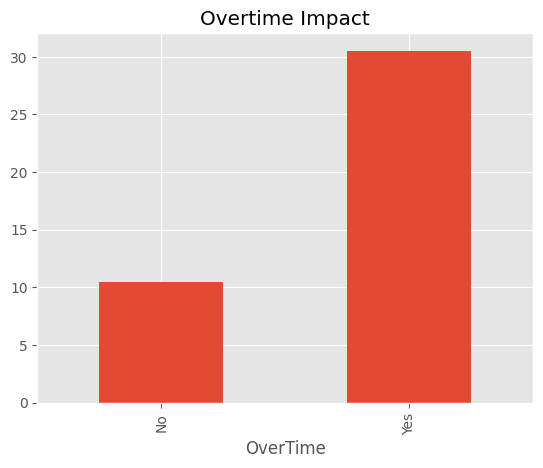

In [ ]:
overtime_attrition=df.groupby('OverTime')['Attrition'].mean()*100

print(overtime_attrition)

overtime_attrition.plot(kind='bar')

plt.title("Overtime Impact")

plt.show()

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64


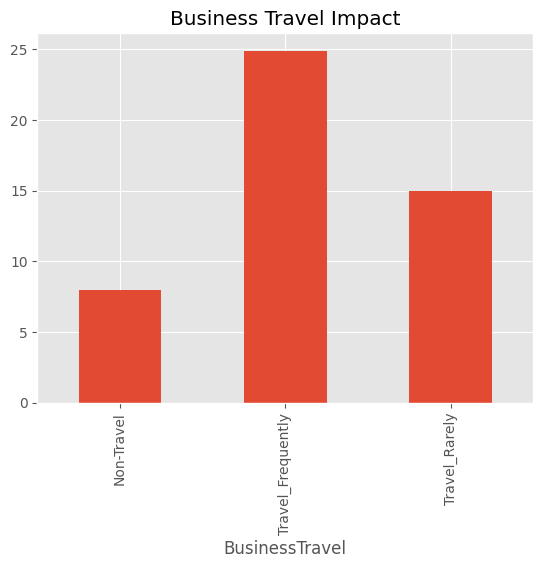

In [ ]:
travel_attrition=df.groupby('BusinessTravel')['Attrition'].mean()*100

print(travel_attrition)

travel_attrition.plot(kind='bar')

plt.title("Business Travel Impact")

plt.show()

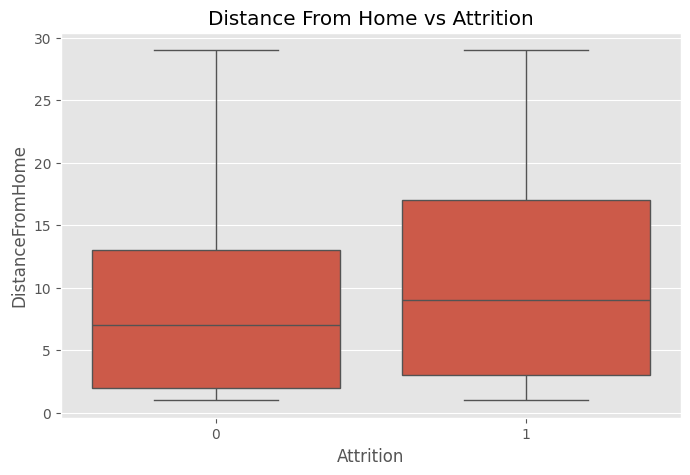

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='DistanceFromHome',
            data=df)

plt.title("Distance From Home vs Attrition")

plt.show()

In [ ]:
risk_hotspots=df.groupby(
['Department','JobRole']
)['Attrition'].mean().reset_index()

risk_hotspots['AttritionRate']=risk_hotspots['Attrition']*100

risk_hotspots=risk_hotspots.sort_values(
'AttritionRate',
ascending=False
)

risk_hotspots.head(15)

,Department,JobRole,Attrition,AttritionRate
10,Sales,Sales Representative,0.397590,39.759036
3,Research & Development,Laboratory Technician,0.239382,23.938224
0,Human Resources,Human Resources,0.230769,23.076923
9,Sales,Sales Executive,0.174847,17.484663
7,Research & Development,Research Scientist,0.160959,16.095890
5,Research & Development,Manufacturing Director,0.068966,6.896552
2,Research & Development,Healthcare Representative,0.068702,6.870229
4,Research & Development,Manager,0.055556,5.555556
8,Sales,Manager,0.054054,5.405405
6,Research & Development,Research Director,0.025000,2.500000


In [ ]:
print("========== EXECUTIVE SUMMARY ==========")

print("Overall Attrition Rate:",
      round(attrition_rate,2),"%")

print("\nTop Attrition Departments:")
print(dept_attrition.sort_values(ascending=False).head())

print("\nTop Attrition Roles:")
print(role_attrition.sort_values(ascending=False).head())

print("\nWorkload Risk Factors:")
print(overtime_attrition)

print("\nTravel Risk Factors:")
print(travel_attrition)

print("\nProject Completed Successfully")

========== EXECUTIVE SUMMARY ==========
Overall Attrition Rate: 16.12 %

Top Attrition Departments:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

Top Attrition Roles:
JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

Workload Risk Factors:
OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

Travel Risk Factors:
BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64

Project Completed Successfully
